In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("cleaned_superstore.csv", encoding="latin1")

print("SUPERSTORE DATASET ANALYSIS")
print(df.head())

SUPERSTORE DATASET ANALYSIS
   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0    6827  CA-2016-118689  02-10-2016  09-10-2016  Standard Class    TC-20980   
1    8154  CA-2017-140151  23-03-2017  25-03-2017     First Class    RB-19360   
2    4191  CA-2017-166709  17-11-2017  22-11-2017  Standard Class    HL-15040   
3    9040  CA-2016-117121  17-12-2016  21-12-2016  Standard Class    AB-10105   
4    4099  CA-2014-116904  23-09-2014  28-09-2014  Standard Class    SC-20095   

   Customer Name    Segment        Country         City  ... Postal Code  \
0   Tamara Chand  Corporate  United States    Lafayette  ...       47905   
1   Raymond Buch   Consumer  United States      Seattle  ...       98115   
2   Hunter Lopez   Consumer  United States       Newark  ...       19711   
3  Adrian Barton   Consumer  United States      Detroit  ...       48205   
4   Sanjit Chand   Consumer  United States  Minneapolis  ...       55407   

    Region       Product ID 

# **Dataset Information**

In [ ]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

# **Summary Statistics**

In [9]:
print(df.describe())

            Row ID   Postal Code     Quantity       Profit
count  9994.000000   9994.000000  9994.000000  9994.000000
mean   4997.500000  55190.379428     3.789574    28.656896
std    2885.163629  32063.693350     2.225110   234.260108
min       1.000000   1040.000000     1.000000 -6599.978000
25%    2499.250000  23223.000000     2.000000     1.728750
50%    4997.500000  56430.500000     3.000000     8.666500
75%    7495.750000  90008.000000     5.000000    29.364000
max    9994.000000  99301.000000    14.000000  8399.976000


# **Total KPIs**

In [11]:
df['Sales'] = df['Sales'].astype(str).str.replace('?', '').str.replace(',', '').astype(float)
df['Profit'] = df['Profit'].astype(str).str.replace('?', '').str.replace(',', '').astype(float)

print("Total Sales:", round(df["Sales"].sum(),2))
print("Total Profit:", round(df["Profit"].sum(),2))
print("Average Sales:", round(df["Sales"].mean(),2))
print("Average Profit:", round(df["Profit"].mean(),2))
print("Total Orders:", df["Order ID"].nunique())

Total Sales: 2297201.07
Total Profit: 286397.02
Average Sales: 229.86
Average Profit: 28.66
Total Orders: 5009


# **Sales by Category**

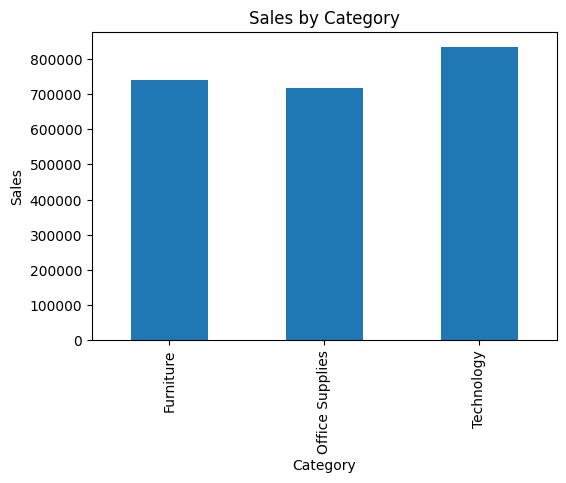

In [12]:
sales_category = df.groupby("Category")["Sales"].sum()

plt.figure(figsize=(6,4))
sales_category.plot(kind="bar")
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.show()

# **Profit by Category**

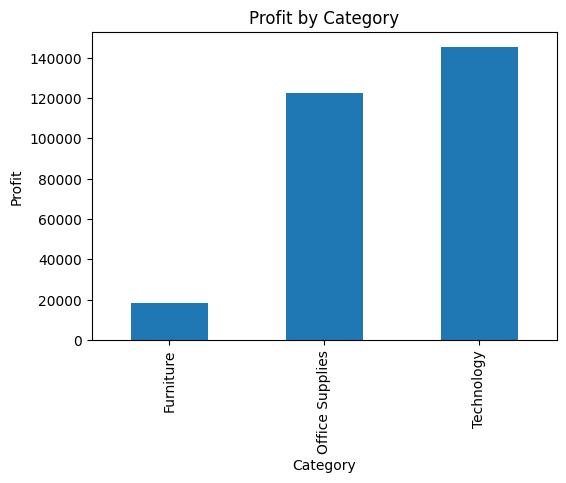

In [13]:
profit_category = df.groupby("Category")["Profit"].sum()

plt.figure(figsize=(6,4))
profit_category.plot(kind="bar")
plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")
plt.show()

# **Sales by Region**

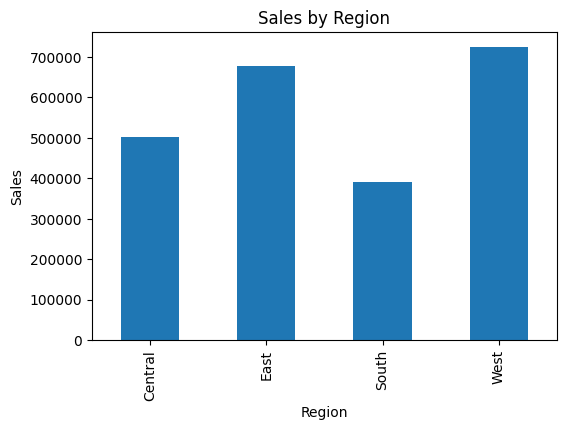

In [14]:
sales_region = df.groupby("Region")["Sales"].sum()

plt.figure(figsize=(6,4))
sales_region.plot(kind="bar")
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.show()

# **Profit by Region**

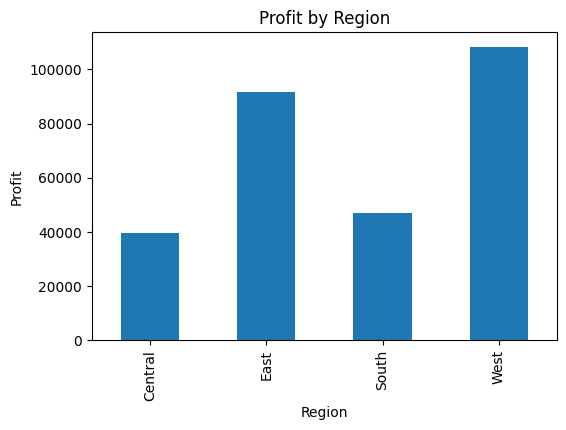

In [15]:
profit_region = df.groupby("Region")["Profit"].sum()

plt.figure(figsize=(6,4))
profit_region.plot(kind="bar")
plt.title("Profit by Region")
plt.xlabel("Region")
plt.ylabel("Profit")
plt.show()

# **Top 10 Products by Sales**

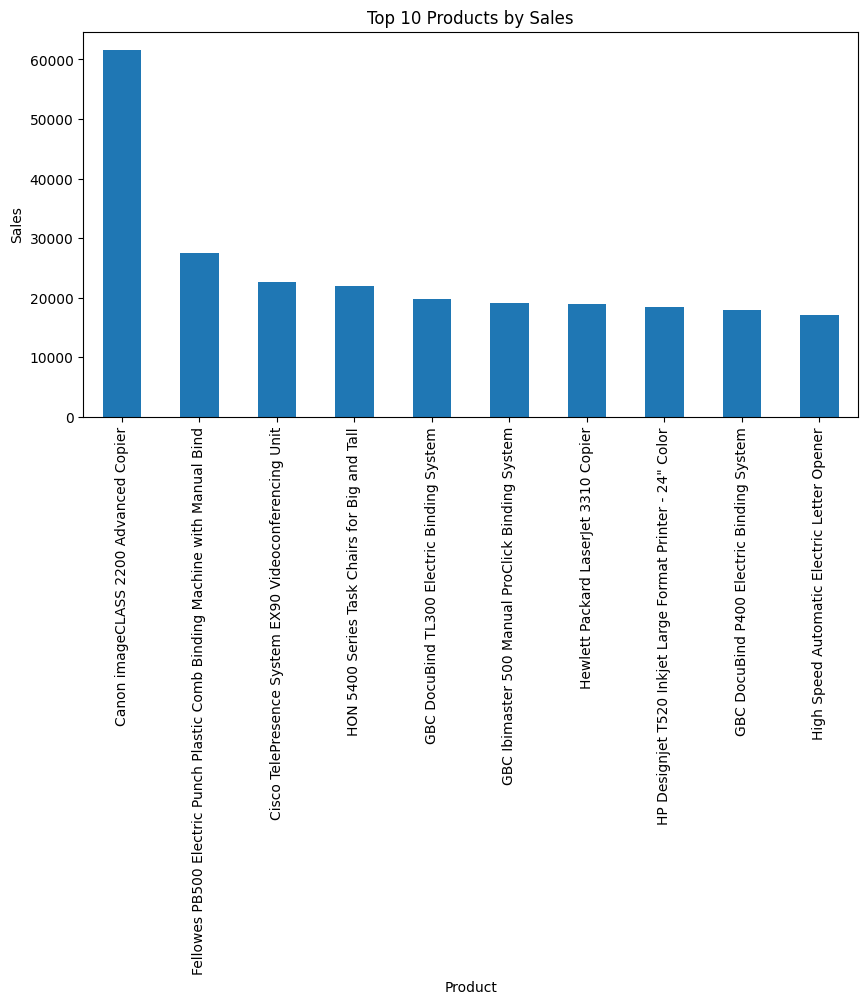

In [16]:
top_products = df.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_products.plot(kind="bar")
plt.title("Top 10 Products by Sales")
plt.xlabel("Product")
plt.ylabel("Sales")
plt.xticks(rotation=90)
plt.show()

# **Monthly Sales Trend**

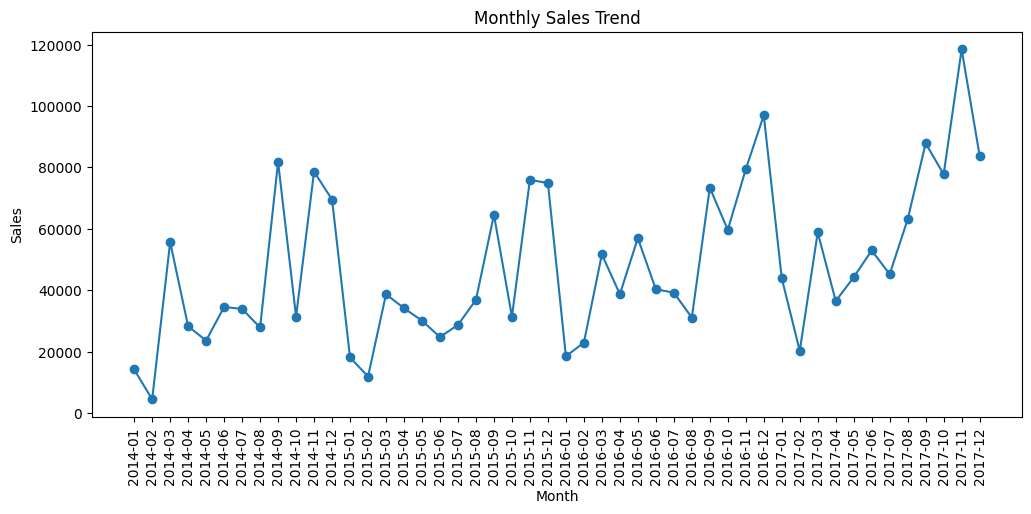

In [17]:
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)

monthly_sales = df.groupby(df["Order Date"].dt.to_period("M"))["Sales"].sum()

monthly_sales.index = monthly_sales.index.astype(str)

plt.figure(figsize=(12,5))
plt.plot(monthly_sales.index, monthly_sales.values, marker="o")
plt.xticks(rotation=90)
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

# **Business Insights**

In [18]:
print("Business Insights")
print("1. Technology category generated the highest sales.")
print("2. Compare category profits to identify the most profitable segment.")
print("3. Regional sales highlight the strongest-performing market.")
print("4. Top-selling products can be prioritized for inventory planning.")
print("5. Monthly sales trend helps identify seasonal demand.")

Business Insights
1. Technology category generated the highest sales.
2. Compare category profits to identify the most profitable segment.
3. Regional sales highlight the strongest-performing market.
4. Top-selling products can be prioritized for inventory planning.
5. Monthly sales trend helps identify seasonal demand.
